## 1. Settings

In [1]:
# libraries
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# garbage collection
import gc
gc.enable()

In [3]:
# pandas options
pd.set_option("display.max_columns", None)

In [4]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# random settings
seed = 42

## 2. Preparation

In [6]:
# dataset
data = "full_cor_2025"

In [7]:
# import data
train = pd.read_csv("../data/prepared/train_" + str(data) + ".csv")
test  = pd.read_csv("../data/prepared/test_"  + str(data) + ".csv")
y     = pd.read_csv("../data/prepared/y_"     + str(data) + ".csv")

In [8]:
# sort data
train = train.sort_values("SK_ID_CURR")
y     = y.sort_values("SK_ID_CURR")

In [9]:
# extract target
y = y["TARGET"]

In [10]:
excluded_feats = ["SK_ID_CURR"]
features = [f for f in train.columns if f not in excluded_feats]
print(train[features].shape)
print(test[features].shape)

(307511, 1335)
(48744, 1335)


## 3. Cross-Validation
### 3.1 All Features

In [11]:
num_folds = 5
shuffle   = True
folds = StratifiedKFold(n_splits = num_folds, random_state = seed, shuffle = shuffle)

# placeholders
valid_aucs_cv = np.zeros(num_folds) 
test_preds_cv = np.zeros(test.shape[0])
feature_importance_df = pd.DataFrame()

In [12]:
### PARAMETERS
import xgboost as xgb
# parallel settings
cores = 10
# lightGBM
import xgboost as xgb

xgbm = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=1000,
    learning_rate=0.05,
    tree_method="hist",
    max_leaves=10,  
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    gamma=0.01,
    min_child_weight=2,
    n_jobs=cores,
    random_state=seed,
    importance_type='gain'
)

In [13]:
num_cols = train[features].select_dtypes(include=[np.number]).columns.tolist()
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y)):
    # data partitioning
    trn_x = train[features].iloc[trn_idx].copy()
    val_x = train[features].iloc[val_idx].copy()
    test_x = test[features].copy()
    
    # -----------------------------
    # 只对数值列替换 inf/-inf 为 NaN
    # -----------------------------
    for col in num_cols:
        trn_x[col] = trn_x[col].replace([np.inf, -np.inf], np.nan)
        val_x[col] = val_x[col].replace([np.inf, -np.inf], np.nan)
        test_x[col] = test_x[col].replace([np.inf, -np.inf], np.nan)

    trn_y = y.iloc[trn_idx].to_numpy().ravel()
    val_y = y.iloc[val_idx].to_numpy().ravel()
    
    # -----------------------------
    # 转换为 numpy 并填充 NaN 为 0
    # -----------------------------
    trn_x = np.nan_to_num(trn_x.to_numpy(), nan=0)
    val_x = np.nan_to_num(val_x.to_numpy(), nan=0)
    test_x = np.nan_to_num(test_x.to_numpy(), nan=0)

    # train XGBoost
    xgbm.fit(
        trn_x, trn_y         # 建议 metric="auc"
        
    )
    valid_preds_cv = xgbm.predict_proba(val_x)[:, 1]
    test_fold_pred = xgbm.predict_proba(test_x)[:, 1]
    valid_aucs_cv[n_fold] = roc_auc_score(val_y, valid_preds_cv)
    test_preds_cv += test_fold_pred / folds.n_splits

    fold_importance_df = pd.DataFrame()
    fold_importance_df["Feature"] = features
    fold_importance_df["Importance"] = xgbm.feature_importances_
    fold_importance_df["Fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis = 0)
    
    print("----------------------")
    print(f"Fold{n_fold+1:2d} AUC: {valid_aucs_cv[n_fold]:.6f}")
    print("----------------------\n")

----------------------
Fold 1 AUC: 0.790519
----------------------

----------------------
Fold 2 AUC: 0.800970
----------------------

----------------------
Fold 3 AUC: 0.791250
----------------------

----------------------
Fold 4 AUC: 0.797364
----------------------

----------------------
Fold 5 AUC: 0.789731
----------------------



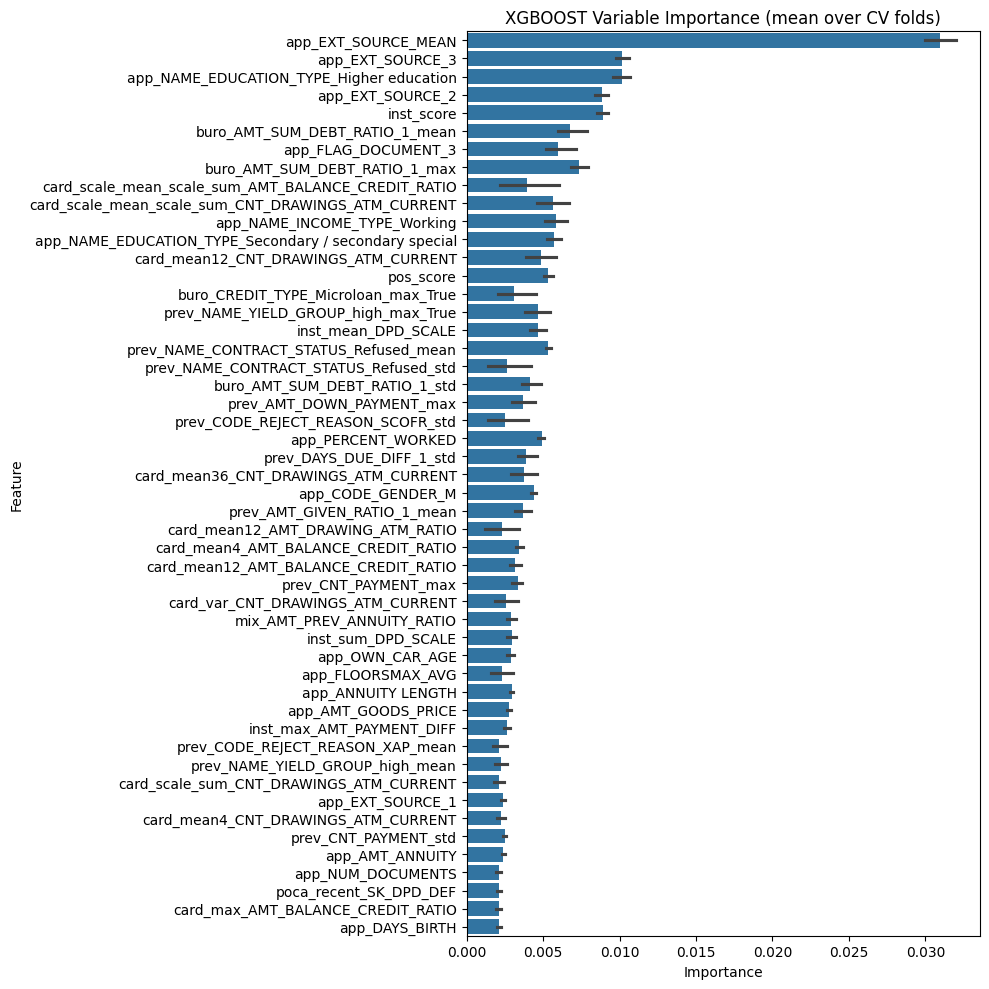

In [14]:
top_feats = 50
cols = feature_importance_df[["Feature", "Importance"]].groupby("Feature").mean().sort_values(by = "Importance", ascending = False)[0:top_feats].index
importance = feature_importance_df.loc[feature_importance_df.Feature.isin(cols)]
    
# plot variable importance
plt.figure(figsize = (10, 10))
sns.barplot(x = "Importance", y = "Feature", data = importance.sort_values(by = "Importance", ascending = False))
plt.title('XGBOOST Variable Importance (mean over CV folds)')
plt.tight_layout()

# save plot as pdf
plt.savefig("../xgb_importance.pdf")

# 4. Submission

In [15]:
# create submission
test["TARGET"] = test_preds_cv
subm = test[["SK_ID_CURR", "TARGET"]]

In [16]:
# export CSV
subm.to_csv("../submissions/auc"  + "_bag_nofunc_xgb" + 'all_feature' + ".csv", index = False, float_format = "%.8f")